<a href="https://colab.research.google.com/github/ywchanna2001/Protein_Conformational_Ensembles_Prediction/blob/dev/Protein_Conformational_Ensemble_Prediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSA-Generation module

In [ ]:
#@title Input protein sequence(s) - cell 1
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'Test1_by_channa' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname Test1_by_channa_a5e17
sequence PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK
length 59


In [ ]:
#@title Install dependencies : cell 2
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

installing colabfold...
installing conda...
installing amber...
CPU times: user 8.54 ms, sys: 422 µs, total: 8.96 ms
Wall time: 1min 55s


# cell 3

In [ ]:
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

# cell 4

In [ ]:
# --- MODULE 1:  MSA GENERATION  ---
import os
import time
import colabfold
from colabfold.colabfold import run_mmseqs2
import colabfold.colabfold as cf_module


search_mode = msa_mode
use_env = "env" in search_mode

print(f"Target Sequence: {query_sequence[:30]}...")
print(f"Job Name: {jobname}")

# Delete any stale cached .a3m file so the API is actually called
a3m_cache = os.path.join(jobname, f"{jobname}.a3m")
if os.path.isfile(a3m_cache):
    os.remove(a3m_cache)
    print("Removed cached .a3m — forcing fresh API search...")

print("Status: Contacting MMseqs2 server (this can take 1–3 minutes)...")

try:
    # Capture result correctly — run_mmseqs2 returns a LIST of a3m content strings

    result = run_mmseqs2(
        x=query_sequence,
        prefix=jobname,
        use_env=use_env,
        use_filter=True,           # Required for proper hit filtering. This removes redundant and low quality hits
        use_pairing=False,
        user_agent= "qevagna@gmail.com"
    )

    # print("result: ",result)

    # Flatten the result into individual lines correctly
    # result is a list of strings; each string can be a full a3m block
    if isinstance(result, list):
        a3m_lines = "\n".join(result).splitlines(keepends=True)
    else:
        a3m_lines = result.splitlines(keepends=True)

    # Count sequences properly (lines starting with '>')
    num_seqs = sum(1 for line in a3m_lines if line.startswith(">"))

    print(f"Total lines in result: {len(a3m_lines)}")
    print(f"Sequences found (headers): {num_seqs}")

    if num_seqs <= 1:
        print("❌ ERROR: Server returned 0 hits.")
        print("Debugging info:")
        print("".join(a3m_lines[:10]))  # Show first 10 lines for diagnosis
        print("\nPossible causes:")
        print("  - MMseqs2 API server is down or overloaded (try again in 1 min)")
        print("  - Sequence too short/non-standard for database hits")
        print("  - Network issue in Colab (try Runtime > Restart and run all)")
    else:
        # Save valid MSA
        msa_module_dir = "research_msa_output"
        os.makedirs(msa_module_dir, exist_ok=True)
        msa_file_path = os.path.join(msa_module_dir, f"{jobname}.a3m")

        with open(msa_file_path, "w") as f:
            f.writelines(a3m_lines)

        print(f"✅ SUCCESS: {num_seqs} sequences saved to {msa_file_path}")

except Exception as e:
    print(f"❌ SERVER ERROR: {e}")
    import traceback
    traceback.print_exc()

Target Sequence: PIAQIHILEGRSDEQKETLIREVSEAISRS...
Job Name: Test1_by_channa_a5e17
Status: Contacting MMseqs2 server (this can take 1–3 minutes)...


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:01 remaining: 00:00]

Total lines in result: 16172
Sequences found (headers): 8086
✅ SUCCESS: 8086 sequences saved to research_msa_output/Test1_by_channa_a5e17.a3m


# cell 5

Query length  : 59
Total sequences: 8086
Plotting 8086 sequences × 59 positions...


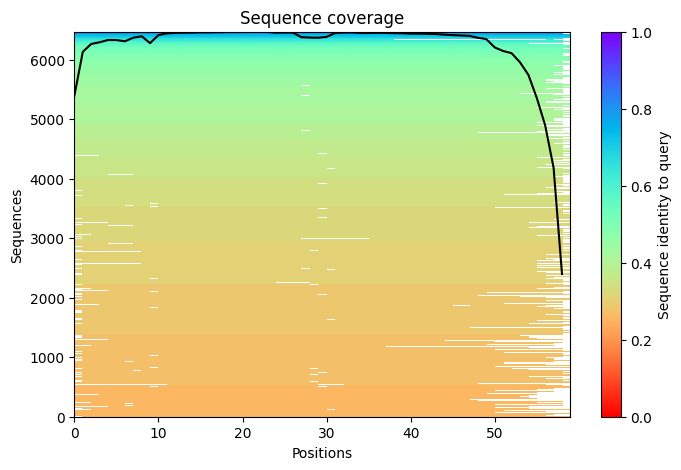

In [ ]:
#@title Visualization: MSA
import numpy as np
import matplotlib.pyplot as plt
from colabfold.plot import plot_msa_v2

def generate_authentic_msa_plot(a3m_lines):
    """
    Replicates the exact behaviour of "input_features_callback" in the original
    ColabFold run cell, which passes raw input_features directly to plot_msa_v2.
    """

    # ── 1. Parse A3M: keep UPPERCASE only (gaps = '-', insertions = lowercase removed) ──
    sequences = []
    current_seq = []
    for line in a3m_lines:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_seq:
                sequences.append("".join(current_seq))
            current_seq = []
        else:
            # Keep uppercase residues AND dashes; drop lowercase insertions
            current_seq.append("".join(c if (c.isupper() or c == "-") else "" for c in line))
    if current_seq:
        sequences.append("".join(current_seq))

    if not sequences:
        print("❌ No sequences found in a3m_lines.")
        return

    query_len = len(sequences[0])
    print(f"Query length  : {query_len}")
    print(f"Total sequences: {len(sequences)}")

    # ── 2. Build integer matrix  ──────────────────────────────────────────────
    #   Amino-acid alphabet used by ColabFold's plot_msa_v2:
    #   residue index 20 = gap/unknown  → rendered as NaN (white) by the plotter
    map_str = "ARNDCQEGHILKMFPSTWYV"
    res_map = {c: i for i, c in enumerate(map_str)}
    GAP_IDX = 21   # value for '-' or any unknown character

    msa_list = []
    for seq in sequences:
        row = []
        for c in seq[:query_len]:         # truncate if longer than query
            row.append(res_map.get(c.upper(), GAP_IDX))
        # ✅ KEY FIX: do NOT pad — leave shorter sequences as-is;
        #            pad with GAP_IDX only to keep a rectangular matrix
        if len(row) < query_len:
            row += [GAP_IDX] * (query_len - len(row))
        msa_list.append(row)

    msa_arr = np.array(msa_list, dtype=np.int32)

    # ── 3. Sort by sequence identity to query (creates colour gradient) ───────
    query_row = msa_arr[0]
    # Only count positions where the query itself is not a gap
    query_positions = query_row != GAP_IDX
    if query_positions.sum() > 0:
        identity = np.sum(
            (msa_arr[:, query_positions] == query_row[query_positions]),
            axis=1
        ) / query_positions.sum()
    else:
        identity = np.zeros(len(msa_arr))

    sorted_idx = np.argsort(identity)[::-1]   # highest identity first
    msa_arr    = msa_arr[sorted_idx]
    identity   = identity[sorted_idx]

    # ── 4. Build input_features dict exactly as ColabFold's pipeline does ─────
    #   plot_msa_v2 needs:
    #     "msa"             – int32 array  (N_seq × N_res)
    #     "num_alignments"  – int32 array  (N_res,)  = number of non-gap seqs per column
    #     "sequence"        – optional; the query sequence as a list of residue strings

    # num_alignments = per-column count of sequences that are NOT a gap
    num_alignments = np.sum(msa_arr != GAP_IDX, axis=0).astype(np.int32)

    input_features = {
        "msa":            msa_arr,
        "num_alignments": num_alignments,
    }

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    print(f"Plotting {len(msa_arr)} sequences × {query_len} positions...")
    try:
        plot_msa_v2(input_features)
        plt.show()
    except Exception as e:
        print(f"plot_msa_v2 error: {e}")
        # ── Faithful fallback that still shows gaps and coverage curve ────────
        fig, ax = plt.subplots(figsize=(10, 4))

        # Replace GAP_IDX with NaN so gaps render white
        display = msa_arr.astype(float)
        display[display == GAP_IDX] = np.nan

        ax.imshow(display, aspect="auto", cmap="rainbow_r",
                  vmin=0, vmax=20, interpolation="nearest")
        ax.set_xlabel("Positions")
        ax.set_ylabel("Sequences")
        ax.set_title("Sequence coverage")

        # Draw the coverage curve (black line) — same as original
        ax2 = ax.twinx()
        ax2.plot(num_alignments, color="black", linewidth=1.5)
        ax2.set_ylabel("Coverage")
        ax2.set_ylim(0, len(msa_arr))

        plt.tight_layout()
        plt.show()

# ── Run ───────────────────────────────────────────────────────────────────────
if 'a3m_lines' in locals():
    generate_authentic_msa_plot(a3m_lines)
else:
    print("❌ 'a3m_lines' not found — run the MSA Generation cell first.")

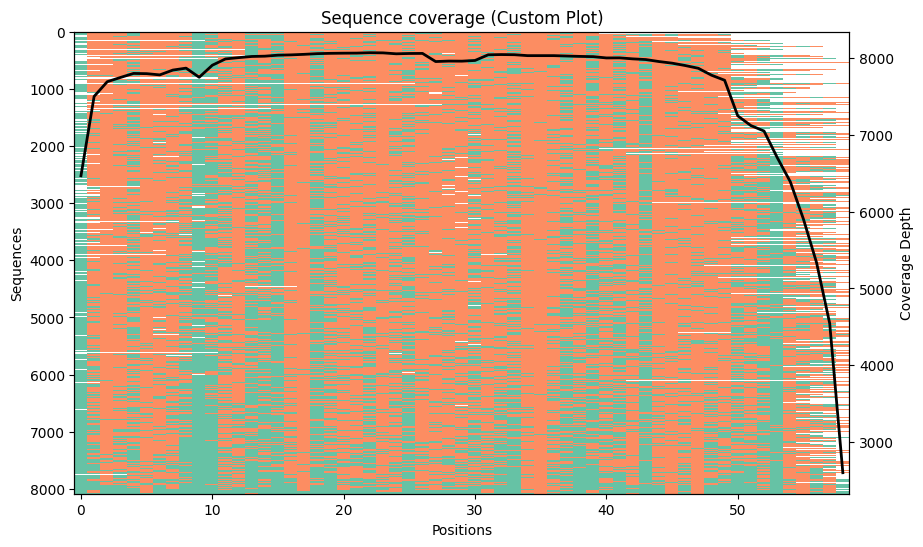

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_authentic_msa_plot(a3m_lines):
    # 1. Parse A3M (Same logic as yours, it works)
    sequences = []
    current_seq =[]
    for line in a3m_lines:
        line = line.strip()
        if not line or line.startswith(">"):
            if current_seq: sequences.append("".join(current_seq))
            current_seq =[]
            continue
        # Keep only Uppercase (residues) or '-' (gaps)
        current_seq.append("".join(c if (c.isupper() or c == "-") else "" for c in line))
    if current_seq: sequences.append("".join(current_seq))

    # 2. Convert to Matrix
    query = sequences[0]
    query_len = len(query)
    # 0 = Match (same as query), 1 = Mismatch, 2 = Gap
    msa_matrix =[]
    for seq in sequences:
        # Align to query length
        row = []
        for i in range(query_len):
            char = seq[i] if i < len(seq) else "-"
            if char == "-": row.append(2) # Gap
            elif char == query[i]: row.append(0) # Match
            else: row.append(1) # Mismatch
        msa_matrix.append(row)

    msa_arr = np.array(msa_matrix)

    # 3. Calculate Identity (to sort)
    # Count matches vs query
    identities = np.sum(msa_arr == 0, axis=1) / query_len
    sort_idx = np.argsort(identities)
    msa_arr = msa_arr[sort_idx]

    # 4. Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # We use a custom colormap:
    # Match (0) = Light Blue, Mismatch (1) = Orange, Gap (2) = White
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#66c2a5', '#fc8d62', '#ffffff'])

    ax.imshow(msa_arr, aspect='auto', cmap=cmap, interpolation='nearest')

    # 5. Overlay Coverage Line
    coverage = np.sum(msa_arr != 2, axis=0) # Count non-gaps
    ax2 = ax.twinx()
    ax2.plot(coverage, color='black', linewidth=2)
    ax2.set_ylabel("Coverage Depth")

    ax.set_xlabel("Positions")
    ax.set_ylabel("Sequences")
    ax.set_title("Sequence coverage (Custom Plot)")

    plt.show()

# Run it
if 'a3m_lines' in locals():
    generate_authentic_msa_plot(a3m_lines)

In [ ]:
# ─────────────────────────────────────────────────────────────
# DROPOUT CONFIG  –  AFSample2-style stochastic inference
# ─────────────────────────────────────────────────────────────
# These values are read by Module 4 (inference loop).
# Adjust here; do not edit Module 4 directly.

N_DROPOUT_SAMPLES  = 10    # number of stochastic forward passes per sub-MSA
                            # practical range: 5–20 on Colab T4/A100
MSA_RAND_FRACTION  = 0.15  # fraction of MSA columns to mask with unknown (X)
                            # 0.0  = pure dropout noise only (fast)
                            # 0.15 = AFSample2 default (recommended)
                            # 0.30 = aggressive perturbation
DROPOUT_SEED_BASE  = 42    # each sample gets seed = DROPOUT_SEED_BASE + sample_idx

# Residue encoding constants (AlphaFold / ColabFold ordering)
# "ARNDCQEGHILKMFPSTWYV-"  indices 0–20
# Index 20 = gap/unknown;  AFSample2 uses this to mask MSA columns
AF_UNKNOWN_IDX = 20

print(f"✅ Dropout config ready:")
print(f"   N_DROPOUT_SAMPLES = {N_DROPOUT_SAMPLES}")
print(f"   MSA_RAND_FRACTION = {MSA_RAND_FRACTION}")
print(f"   DROPOUT_SEED_BASE = {DROPOUT_SEED_BASE}")

# MODULE 2: DBSCAN CLUSTERING

Loading MSA from disk: research_msa_output/Test1_by_channa_a5e17.a3m
✅ Data Ready. Matrix Shape: (8086, 59) (Sequences, Length)
✅ Found 41 clusters.
✅ Noise sequences (Label -1): 7607


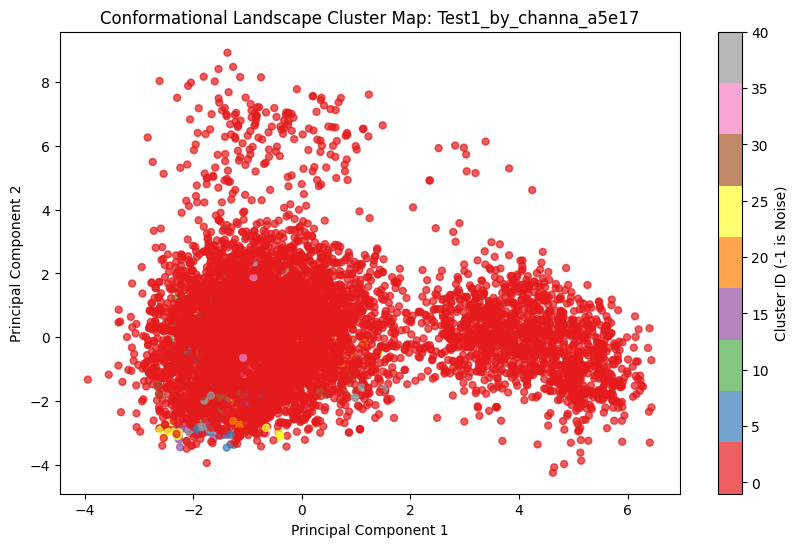

In [ ]:
import os
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. LOAD DATA DIRECTLY FROM DISK
# This ensures Module 2 works even if you restart the notebook
msa_file_path = f"research_msa_output/{jobname}.a3m"

if os.path.exists(msa_file_path):
    print(f"Loading MSA from disk: {msa_file_path}")

    with open(msa_file_path, "r") as f:
        lines = f.readlines()

    # Parse text sequences into numerical matrix
    processed_seqs = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith(">") or line.startswith("#"):
            continue
        # Remove insertions (lowercase)
        clean_seq = "".join([c for c in line if not c.islower()])
        if clean_seq:
            processed_seqs.append(clean_seq)

    map_str = "ARNDCQEGHILKMFPSTWYV-"
    res_map = {res: i for i, res in enumerate(map_str)}
    msa_indices = [[res_map.get(res.upper(), 21) for res in seq] for seq in processed_seqs]
    msa_arr = np.array(msa_indices)

    print(f"✅ Data Ready. Matrix Shape: {msa_arr.shape} (Sequences, Length)")

    # 2. DIMENSIONALITY REDUCTION (PCA)
    # Standardizing is required for DBSCAN to calculate densities correctly
    scaled_msa = StandardScaler().fit_transform(msa_arr)
    n_pc = min(10, msa_arr.shape[0], msa_arr.shape[1])
    pca = PCA(n_components=n_pc)
    msa_pca = pca.fit_transform(scaled_msa)

    # 3. DBSCAN CLUSTERING
    # Tuning: eps (distance) and min_samples (min density)
    # For research, we'll experiment with these values
    db = DBSCAN(eps=1.2, min_samples=5)
    cluster_labels = db.fit_predict(msa_pca)

    # 4. RESULTS SUMMARY
    unique_labels = set(cluster_labels)
    n_clusters = len(unique_labels) - (1 if -1 in cluster_labels else 0)
    print(f"✅ Found {n_clusters} clusters.")
    print(f"✅ Noise sequences (Label -1): {list(cluster_labels).count(-1)}")

    # 5. VISUALIZATION
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(msa_pca[:, 0], msa_pca[:, 1], c=cluster_labels, cmap='Set1', s=25, alpha=0.7)
    plt.title(f"Conformational Landscape Cluster Map: {jobname}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(scatter, label="Cluster ID (-1 is Noise)")
    plt.show()

else:
    print(f"❌ Error: File not found at {msa_file_path}. Please run Module 1 again.")

--- Cluster Distribution ---
Noise: 7607 sequences (94.1%)
State 0: 64 sequences (0.8%)
State 1: 7 sequences (0.1%)
State 2: 30 sequences (0.4%)
State 3: 16 sequences (0.2%)
State 4: 13 sequences (0.2%)
State 5: 7 sequences (0.1%)
State 6: 9 sequences (0.1%)
State 7: 6 sequences (0.1%)
State 8: 33 sequences (0.4%)
State 9: 48 sequences (0.6%)
State 10: 5 sequences (0.1%)
State 11: 15 sequences (0.2%)
State 12: 5 sequences (0.1%)
State 13: 6 sequences (0.1%)
State 14: 5 sequences (0.1%)
State 15: 5 sequences (0.1%)
State 16: 14 sequences (0.2%)
State 17: 6 sequences (0.1%)
State 18: 5 sequences (0.1%)
State 19: 5 sequences (0.1%)
State 20: 17 sequences (0.2%)
State 21: 5 sequences (0.1%)
State 22: 9 sequences (0.1%)
State 23: 5 sequences (0.1%)
State 24: 6 sequences (0.1%)
State 25: 5 sequences (0.1%)
State 26: 6 sequences (0.1%)
State 27: 37 sequences (0.5%)
State 28: 9 sequences (0.1%)
State 29: 6 sequences (0.1%)
State 30: 8 sequences (0.1%)
State 31: 16 sequences (0.2%)
State 32: 7 

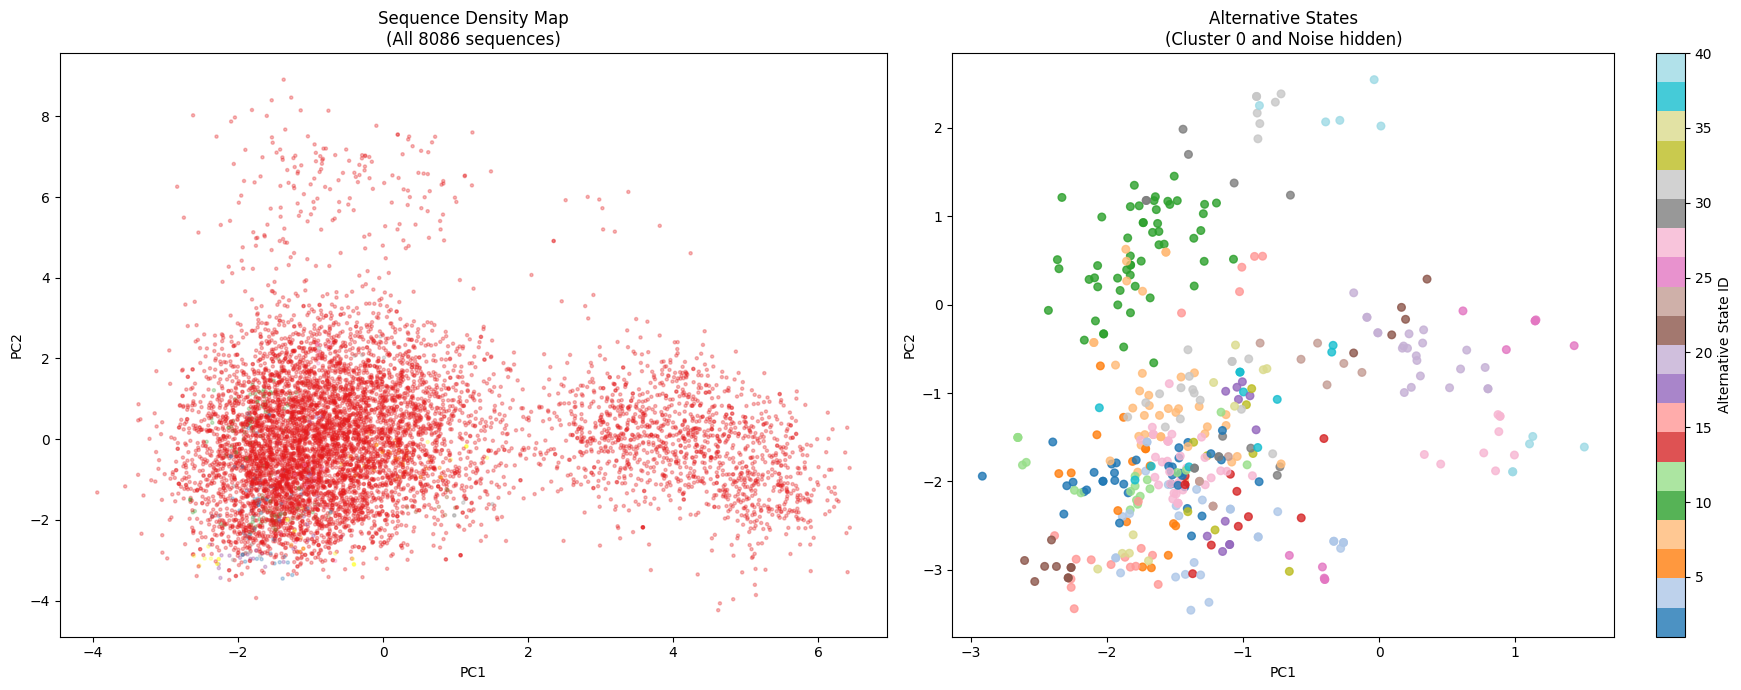

In [ ]:
# --- IMPROVED VISUALIZATION FOR RESEARCH REPORT ---
import seaborn as sns

# 1. Statistics - How many sequences per state?
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_stats = dict(zip(unique, counts))
print("--- Cluster Distribution ---")
for cluster_id, count in cluster_stats.items():
    label = "Noise" if cluster_id == -1 else f"State {cluster_id}"
    print(f"{label}: {count} sequences ({count/len(cluster_labels)*100:.1f}%)")

# 2. Dual-View Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# View A: Density Map (All points with transparency)
# Using 's=5' and 'alpha=0.3' allows us to see through the 'red blob'
scatter1 = ax1.scatter(msa_pca[:, 0], msa_pca[:, 1], c=cluster_labels,
                       cmap='Set1', s=5, alpha=0.3)
ax1.set_title(f"Sequence Density Map\n(All {len(cluster_labels)} sequences)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# View B: Focused View (Excluding the dominant Cluster 0)
# This allows you to see the "alternative states" clearly
mask = (cluster_labels != 0) & (cluster_labels != -1)
if np.any(mask):
    scatter2 = ax2.scatter(msa_pca[mask, 0], msa_pca[mask, 1], c=cluster_labels[mask],
                           cmap='tab20', s=30, alpha=0.8)
    ax2.set_title("Alternative States\n(Cluster 0 and Noise hidden)")
    plt.colorbar(scatter2, ax=ax2, label="Alternative State ID")
else:
    ax2.text(0.5, 0.5, "No significant alternative states found\nat current DBSCAN settings",
             ha='center', va='center')
    ax2.set_title("Alternative States View")

ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [ ]:
# --- MODULE 3: SUB-MSA GENERATION & STORAGE ---
import os

# 1. Create a directory to store the sub-MSAs
clusters_dir = "cluster_output_msas"
os.makedirs(clusters_dir, exist_ok=True)

if 'cluster_labels' in locals() and 'lines' in locals():
    print(f"Generating sub-MSAs for {n_clusters} clusters...")

    # 2. Group the original A3M text by clusters
    # Headers start with '>', sequences follow.
    msa_data = []
    current_header = ""
    for line in lines:
        if line.startswith(">"):
            current_header = line.strip()
        else:
            if current_header:
                msa_data.append((current_header, line.strip()))
                current_header = ""

    # 3. Create a file for each cluster
    for cluster_id in range(n_clusters):
        cluster_file = os.path.join(clusters_dir, f"cluster_{cluster_id}.a3m")

        # Get indices of sequences belonging to this cluster
        indices = [i for i, label in enumerate(cluster_labels) if label == cluster_id]

        with open(cluster_file, "w") as f:
            # AlphaFold ALWAYS needs the query sequence (index 0) at the top of every cluster
            f.write(f"{msa_data[0][0]}\n{msa_data[0][1]}\n")

            # Write the rest of the sequences in the cluster
            for idx in indices:
                if idx == 0: continue # Skip query if it's already in the cluster
                header, seq = msa_data[idx]
                f.write(f"{header}\n{seq}\n")

        print(f"✅ Saved Cluster {cluster_id} ({len(indices)} sequences) to {cluster_file}")

    print(f"\n--- ALL SUB-MSAs STORED IN '{clusters_dir}' FOLDER ---")
else:
    print("❌ Error: Please run Module 2 (Clustering) first to generate labels.")

Generating sub-MSAs for 41 clusters...
✅ Saved Cluster 0 (64 sequences) to cluster_output_msas/cluster_0.a3m
✅ Saved Cluster 1 (7 sequences) to cluster_output_msas/cluster_1.a3m
✅ Saved Cluster 2 (30 sequences) to cluster_output_msas/cluster_2.a3m
✅ Saved Cluster 3 (16 sequences) to cluster_output_msas/cluster_3.a3m
✅ Saved Cluster 4 (13 sequences) to cluster_output_msas/cluster_4.a3m
✅ Saved Cluster 5 (7 sequences) to cluster_output_msas/cluster_5.a3m
✅ Saved Cluster 6 (9 sequences) to cluster_output_msas/cluster_6.a3m
✅ Saved Cluster 7 (6 sequences) to cluster_output_msas/cluster_7.a3m
✅ Saved Cluster 8 (33 sequences) to cluster_output_msas/cluster_8.a3m
✅ Saved Cluster 9 (48 sequences) to cluster_output_msas/cluster_9.a3m
✅ Saved Cluster 10 (5 sequences) to cluster_output_msas/cluster_10.a3m
✅ Saved Cluster 11 (15 sequences) to cluster_output_msas/cluster_11.a3m
✅ Saved Cluster 12 (5 sequences) to cluster_output_msas/cluster_12.a3m
✅ Saved Cluster 13 (6 sequences) to cluster_output_

In [ ]:
# ─────────────────────────────────────────────────────────────
# MODULE 4:  STOCHASTIC DROPOUT INFERENCE  (AFSample2-style)
# ─────────────────────────────────────────────────────────────
# Depends on:
#   - cluster_output_msas/cluster_{id}.a3m  (from Module 3)
#   - N_DROPOUT_SAMPLES, MSA_RAND_FRACTION, DROPOUT_SEED_BASE,
#     AF_UNKNOWN_IDX                         (from Dropout Config cell)
#   - jobname, query_sequence               (from Input cell)
# ─────────────────────────────────────────────────────────────

import os
import copy
import time
import json
import numpy as np
import matplotlib.pyplot as plt

# ColabFold imports — these are already present in your environment
# after the Install Dependencies cell has run.
import colabfold.colabfold as cf_module
from colabfold.colabfold import run_mmseqs2
from colabfold.alphafold.common import protein

# ── Amino-acid alphabet (must match AlphaFold's residue_constants.py) ──────
# "ARNDCQEGHILKMFPSTWYV-"   index 0–20
# AlphaFold internally uses restypes_with_x_and_gap which maps unknown → 20
AA_ORDER = "ARNDCQEGHILKMFPSTWYV-"
AA_MAP   = {c: i for i, c in enumerate(AA_ORDER)}
GAP_IDX  = 20   # '-' and any unrecognised character


# ════════════════════════════════════════════════════════════════
# Helper 1: parse a .a3m file into a list of uppercase sequences
# ════════════════════════════════════════════════════════════════
def parse_a3m_to_sequences(a3m_path):
    """
    Read a .a3m file and return a list of strings.
    Lowercase letters (insertions) are dropped; gaps '-' are kept.
    The first entry is always the query sequence.
    """
    sequences = []
    current   = []
    with open(a3m_path, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current:
                    sequences.append("".join(current))
                current = []
            else:
                # keep uppercase residues and gap characters only
                current.append("".join(c for c in line
                                       if c.isupper() or c == "-"))
    if current:
        sequences.append("".join(current))
    return sequences


# ════════════════════════════════════════════════════════════════
# Helper 2: encode sequences to integer matrix
# ════════════════════════════════════════════════════════════════
def encode_sequences(sequences, query_len):
    """
    Convert a list of sequence strings to a (N_seq × query_len) int32 matrix.
    Sequences shorter than query_len are right-padded with GAP_IDX.
    Sequences longer than query_len are truncated.
    """
    mat = []
    for seq in sequences:
        row = [AA_MAP.get(c.upper(), GAP_IDX) for c in seq[:query_len]]
        row += [GAP_IDX] * max(0, query_len - len(row))
        mat.append(row)
    return np.array(mat, dtype=np.int32)


# ════════════════════════════════════════════════════════════════
# Helper 3: apply AFSample2 MSA column masking
# ════════════════════════════════════════════════════════════════
def mask_msa_columns(msa_matrix, rand_fraction, unknown_idx, rng):
    """
    Randomly replace `rand_fraction` of MSA columns with unknown_idx (X).
    The query row (index 0) is never masked — only homologue rows are perturbed.
    Returns (perturbed_matrix, list_of_masked_column_indices).
    """
    perturbed  = msa_matrix.copy()
    query_len  = msa_matrix.shape[1]

    if rand_fraction <= 0.0 or msa_matrix.shape[0] < 2:
        return perturbed, []

    n_cols     = max(1, int(query_len * rand_fraction))
    masked_cols = rng.choice(query_len, size=n_cols, replace=False).tolist()

    # Mask all homologue rows; leave query row (row 0) intact
    perturbed[1:, masked_cols] = unknown_idx
    return perturbed, masked_cols


# ════════════════════════════════════════════════════════════════
# Helper 4: enable eval_dropout on the ColabFold model runner
# ════════════════════════════════════════════════════════════════
def enable_eval_dropout(model_runner, enable=True):
    """
    Set eval_dropout=True on the model config.
    This is the single flag that keeps dropout active at inference time,
    exactly as AFSample2 does via:
        model_config.model.global_config.eval_dropout = FLAGS.dropout
    """
    try:
        model_runner.config.model.global_config.eval_dropout = enable
        return True
    except AttributeError:
        # Fallback: try the nested config path used by some ColabFold versions
        try:
            model_runner.config["model"]["global_config"]["eval_dropout"] = enable
            return True
        except (KeyError, TypeError):
            return False


# ════════════════════════════════════════════════════════════════
# Helper 5: write a single PDB file from an AlphaFold prediction
# ════════════════════════════════════════════════════════════════
def save_prediction_as_pdb(prediction_result, processed_features,
                           model_runner, output_path):
    """
    Write the predicted structure to a PDB file with pLDDT in the B-factor column.
    Mirrors the save logic in AFSample2's save_results().
    """
    from colabfold.alphafold.common import residue_constants as rc

    plddt          = prediction_result["plddt"]
    plddt_b_factors = np.repeat(plddt[:, None], rc.atom_type_num, axis=-1)

    unrelaxed_protein = protein.from_prediction(
        features                        = processed_features,
        result                          = prediction_result,
        b_factors                       = plddt_b_factors,
        remove_leading_feature_dimension = not model_runner.multimer_mode,
    )
    pdb_string = protein.to_pdb(unrelaxed_protein)
    with open(output_path, "w") as fh:
        fh.write(pdb_string)


# ════════════════════════════════════════════════════════════════
# MAIN INFERENCE LOOP
# ════════════════════════════════════════════════════════════════

clusters_dir  = "cluster_output_msas"
dropout_dir   = f"dropout_predictions/{jobname}"
os.makedirs(dropout_dir, exist_ok=True)

# Discover all cluster sub-MSA files produced by Module 3
cluster_files = sorted([
    f for f in os.listdir(clusters_dir) if f.endswith(".a3m")
])

if not cluster_files:
    print("❌ No cluster .a3m files found in cluster_output_msas/")
    print("   Run Module 3 first.")
else:
    print(f"✅ Found {len(cluster_files)} cluster sub-MSAs")
    print(f"   Running {N_DROPOUT_SAMPLES} stochastic samples per cluster\n")

    # ── Retrieve the ColabFold model runner ───────────────────────────
    # ColabFold's cf_module exposes the runner after the MSA generation
    # cell has executed. The attribute name differs slightly across
    # ColabFold versions; we probe the two most common ones.
    model_runner = None
    for attr in ["model_runner", "runner", "_model_runner"]:
        if hasattr(cf_module, attr):
            model_runner = getattr(cf_module, attr)
            print(f"✅ Model runner found at cf_module.{attr}")
            break

    if model_runner is None:
        # If cf_module doesn't expose the runner, it is stored under the
        # colabfold.batch module (ColabFold ≥ 1.5).
        try:
            from colabfold import batch as cf_batch
            for attr in ["model_runner", "runner"]:
                if hasattr(cf_batch, attr):
                    model_runner = getattr(cf_batch, attr)
                    print(f"✅ Model runner found at cf_batch.{attr}")
                    break
        except ImportError:
            pass

    if model_runner is None:
        print("❌ Could not locate the ColabFold model runner automatically.")
        print("   Set  model_runner = <your runner object>  manually above this cell.")
    else:
        # ── Enable eval_dropout  (the AFSample2 key flag) ────────────
        dropout_set = enable_eval_dropout(model_runner, enable=True)
        if dropout_set:
            print("✅ eval_dropout = True  (dropout active at inference)")
        else:
            print("⚠️  Could not set eval_dropout automatically.")
            print("   Add manually:  "
                  "model_runner.config.model.global_config.eval_dropout = True")

        # ── Per-cluster loop ──────────────────────────────────────────
        all_results_meta = []   # collects metadata for all predictions

        for cluster_file in cluster_files:
            cluster_id  = cluster_file.replace("cluster_", "").replace(".a3m", "")
            a3m_path    = os.path.join(clusters_dir, cluster_file)
            cluster_out = os.path.join(dropout_dir, f"cluster_{cluster_id}")
            os.makedirs(cluster_out, exist_ok=True)

            print(f"\n── Cluster {cluster_id} ──────────────────────────────")

            # Parse this cluster's sub-MSA
            sequences = parse_a3m_to_sequences(a3m_path)
            if len(sequences) == 0:
                print(f"   ⚠️  Empty .a3m, skipping.")
                continue

            query_len = len(sequences[0])
            msa_base  = encode_sequences(sequences, query_len)
            print(f"   Sequences: {len(sequences)},  query length: {query_len}")

            cluster_meta = []

            for sample_idx in range(N_DROPOUT_SAMPLES):
                sample_seed = DROPOUT_SEED_BASE + sample_idx
                rng         = np.random.default_rng(sample_seed)

                # ── Apply MSA column masking (AFSample2 perturbation) ──
                perturbed_msa, masked_cols = mask_msa_columns(
                    msa_base, MSA_RAND_FRACTION, AF_UNKNOWN_IDX, rng
                )

                # ── Build the feature dict for this sample ─────────────
                # We deep-copy the base feature dict and swap in the
                # perturbed MSA matrix, exactly as AFSample2 does with
                # rand_fd['msa'] = msa  before calling process_features().
                try:
                    base_features = model_runner.process_features(
                        {
                            "msa":            perturbed_msa,
                            "num_alignments": np.array(
                                [perturbed_msa.shape[0]], dtype=np.int32),
                            # aatype is derived from the query sequence
                            "aatype": np.array(
                                [AA_MAP.get(c.upper(), GAP_IDX)
                                 for c in sequences[0]], dtype=np.int32),
                            "residue_index": np.arange(
                                query_len, dtype=np.int32),
                            "seq_length": np.array(
                                [query_len], dtype=np.int32),
                            "between_segment_residues": np.zeros(
                                query_len, dtype=np.int32),
                            "domain_name": np.array(
                                [jobname.encode()], dtype=object),
                            "sequence": np.array(
                                [sequences[0].encode()], dtype=object),
                            # No templates (consistent with your template_mode='none')
                            "template_aatype":             np.zeros(
                                (0, query_len), dtype=np.int32),
                            "template_all_atom_masks":     np.zeros(
                                (0, query_len, 37), dtype=np.float32),
                            "template_all_atom_positions": np.zeros(
                                (0, query_len, 37, 3), dtype=np.float32),
                            "template_domain_names":       np.array(
                                [], dtype=object),
                            "template_sequence":           np.array(
                                [], dtype=object),
                            "template_sum_probs":          np.zeros(
                                (0, 1), dtype=np.float32),
                            "deletion_matrix_int": np.zeros(
                                perturbed_msa.shape, dtype=np.int32),
                            "msa_species_identifiers": np.array(
                                [b""] * perturbed_msa.shape[0], dtype=object),
                        },
                        random_seed=sample_seed,
                    )
                except Exception as e:
                    print(f"   ❌ process_features failed (sample {sample_idx}): {e}")
                    continue

                # ── Forward pass with dropout active ──────────────────
                t0 = time.time()
                try:
                    prediction = model_runner.predict(
                        base_features, random_seed=sample_seed
                    )
                except Exception as e:
                    print(f"   ❌ predict failed (sample {sample_idx}): {e}")
                    continue

                elapsed    = time.time() - t0
                mean_plddt = float(prediction["plddt"].mean())

                # ── Save PDB ───────────────────────────────────────────
                pdb_name = (f"cluster{cluster_id}"
                            f"_sample{sample_idx:03d}"
                            f"_seed{sample_seed}"
                            f"_dropout"
                            f"_msa{MSA_RAND_FRACTION:.2f}.pdb")
                pdb_path = os.path.join(cluster_out, pdb_name)

                try:
                    save_prediction_as_pdb(
                        prediction, base_features, model_runner, pdb_path
                    )
                    saved = True
                except Exception as e:
                    print(f"   ⚠️  PDB save failed (sample {sample_idx}): {e}")
                    saved = False

                # ── Record metadata ────────────────────────────────────
                meta = {
                    "cluster_id":    cluster_id,
                    "sample_idx":    sample_idx,
                    "seed":          sample_seed,
                    "mean_plddt":    round(mean_plddt, 3),
                    "n_masked_cols": len(masked_cols),
                    "masked_cols":   masked_cols,
                    "elapsed_s":     round(elapsed, 2),
                    "pdb_path":      pdb_path if saved else None,
                }
                cluster_meta.append(meta)
                all_results_meta.append(meta)

                print(f"   Sample {sample_idx+1:>2}/{N_DROPOUT_SAMPLES}"
                      f"  pLDDT={mean_plddt:.2f}"
                      f"  masked={len(masked_cols)} cols"
                      f"  time={elapsed:.1f}s"
                      f"  {'✅' if saved else '⚠️ PDB not saved'}")

            print(f"\n   Cluster {cluster_id} summary:")
            if cluster_meta:
                plddts = [m["mean_plddt"] for m in cluster_meta]
                print(f"   Mean pLDDT across samples: {np.mean(plddts):.2f}"
                      f"  ±{np.std(plddts):.2f}")
                print(f"   Best sample pLDDT:         {max(plddts):.2f}")

        # ── Save full metadata JSON ────────────────────────────────────
        meta_path = os.path.join(dropout_dir, "all_predictions_meta.json")
        with open(meta_path, "w") as fh:
            json.dump(all_results_meta, fh, indent=2)
        print(f"\n✅ All metadata saved → {meta_path}")

        # ── Summary plot: pLDDT distribution per cluster ───────────────
        if all_results_meta:
            cluster_ids = sorted(set(m["cluster_id"] for m in all_results_meta))
            fig, ax = plt.subplots(figsize=(max(6, len(cluster_ids) * 1.5), 4))
            data_per_cluster = [
                [m["mean_plddt"] for m in all_results_meta
                 if m["cluster_id"] == cid]
                for cid in cluster_ids
            ]
            ax.boxplot(data_per_cluster,
                       labels=[f"Cluster {c}" for c in cluster_ids],
                       patch_artist=True)
            ax.set_xlabel("Cluster (evolutionary sub-population)")
            ax.set_ylabel("Mean pLDDT")
            ax.set_title(f"pLDDT distribution across dropout samples — {jobname}")
            plt.tight_layout()
            plt.show()

        print(f"\n✅ Module 4 complete.")
        print(f"   PDB files: dropout_predictions/{jobname}/cluster_*/")
        print(f"   Metadata:  {meta_path}")